# 03 — Spatial validation

## What this notebook does
1. **Spatial autocorrelation** — Moran's I for target variables.
2. **Spatial clustering diagnostics** — clusters on a map, sample counts, and size distribution.
3. **Random vs spatial CV** — compare a baseline model under KFold vs SpatialGroupKFold.
4. **Interpretation** — spatial structure, implications for validation, and limitations.

## Why spatial validation is required
In geospatial ML, **nearby samples are similar** (terrain, climate, land cover). A **random** train/test split puts neighbors in both sets. The model then "sees" the landscape indirectly and **test error is optimistically low**. For **prediction at new locations**, you need folds that **separate regions** — e.g. hold out whole spatial groups.

## Scientific reasoning
This mimics **transfer to unsampled areas** (new catchments or regions). Metrics from spatial CV are usually **worse** than random CV but **more honest** for mapping and management use.


In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
import sys
sys.path.insert(0, str(ROOT))

from src.validation.spatial_cv import spatial_cluster_groups, SpatialGroupKFold
from src.visualization.maps import plot_spatial_clusters
from src.features.preprocess import feature_columns, impute_median

RAW = ROOT / "data" / "raw"
for name in ["water_quality_dataset_v1.csv", "water_quality.csv"]:
    csv_path = RAW / name
    if csv_path.exists():
        break
else:
    raise FileNotFoundError("No data/raw/water_quality_dataset_v1.csv or water_quality.csv found.")
df = pd.read_csv(csv_path)
# Normalize lat/lon and target column names (as in load_water_quality_data)
if "Latitude" in df.columns and "lat" not in df.columns:
    df["lat"] = df["Latitude"]
if "Longitude" in df.columns and "lon" not in df.columns:
    df["lon"] = df["Longitude"]
for old, new in [("Total Alkalinity", "total_alkalinity"), ("Electrical Conductance", "electrical_conductance"), ("Dissolved Reactive Phosphorus", "dissolved_reactive_phosphorus")]:
    if old in df.columns and new not in df.columns:
        df[new] = df[old]
lat = df["lat"] if "lat" in df.columns else df["Latitude"]
lon = df["lon"] if "lon" in df.columns else df["Longitude"]
lat_arr = np.asarray(lat, dtype=float)
lon_arr = np.asarray(lon, dtype=float)
print(f"Loaded: {csv_path.name} | n = {len(df)}")

Loaded: water_quality_dataset_v1.csv | n = 9319


# 1. Spatial autocorrelation analysis

**Moran's I** measures whether nearby locations have similar values (positive I) or dissimilar values (negative I). Values near 0 suggest little spatial structure. If targets show significant positive autocorrelation, nearby sites are similar and **random splits will leak information**; spatial CV is then necessary for honest performance estimates.

In [4]:
def morans_i(x, coords, max_samples=2500, k_neighbors=10):
    """Moran's I using inverse-distance weights and k-nearest neighbors (subsample if n > max_samples)."""
    n = len(x)
    x = np.asarray(x, dtype=float).ravel()
    coords = np.asarray(coords, dtype=float)
    if coords.shape[0] != n:
        coords = coords[:n]
    if n > max_samples:
        rng = np.random.default_rng(42)
        idx = rng.choice(n, size=max_samples, replace=False)
        x, coords = x[idx], coords[idx]
        n = len(x)
    x = x.copy()
    x = x - np.nanmean(x)
    valid = np.isfinite(x)
    if np.sum(valid) < 20:
        return np.nan, np.nan
    x = x[valid]
    coords = coords[valid]
    n = len(x)
    d = squareform(pdist(coords, "euclidean"))
    np.fill_diagonal(d, np.inf)
    w = np.zeros_like(d)
    for i in range(n):
        nbr = np.argpartition(d[i], k_neighbors)[:k_neighbors]
        w[i, nbr] = 1.0 / (d[i, nbr] + 1e-6)
    w = (w + w.T) / 2
    W = w.sum()
    if W <= 0:
        return np.nan, np.nan
    numer = np.sum(w * np.outer(x, x))
    denom = np.sum(x ** 2)
    if denom <= 0:
        return np.nan, np.nan
    I = (n / W) * (numer / denom)
    # Permutation std for a simple z-score (approximate)
    n_perm = 99
    I_perm = []
    for _ in range(n_perm):
        x_perm = np.random.permutation(x)
        numer_p = np.sum(w * np.outer(x_perm, x_perm))
        I_perm.append((n / W) * (numer_p / denom))
    I_perm = np.array(I_perm)
    z = (I - np.mean(I_perm)) / (np.std(I_perm) + 1e-10)
    return float(I), float(z)

TARGETS = ["total_alkalinity", "electrical_conductance", "dissolved_reactive_phosphorus"]
coords = np.column_stack([lat_arr, lon_arr])
print("Moran's I (subsample n≈2500, k=10 neighbors):")
print("-" * 55)
for t in TARGETS:
    if t not in df.columns:
        continue
    y = df[t].values.copy()
    I, z = morans_i(y, coords)
    sig = "***" if abs(z) > 2.58 else "**" if abs(z) > 1.96 else "*" if abs(z) > 1.65 else ""
    print(f"  {t}: I = {I:.4f}  z ≈ {z:.2f} {sig}")
print("-" * 55)
print("(*) |z|>1.65  (**) |z|>1.96  (***) |z|>2.58")

Moran's I (subsample n≈2500, k=10 neighbors):
-------------------------------------------------------
  total_alkalinity: I = 0.7943  z ≈ 93.07 ***
  electrical_conductance: I = 0.7897  z ≈ 92.07 ***
  dissolved_reactive_phosphorus: I = 0.5536  z ≈ 71.95 ***
-------------------------------------------------------
(*) |z|>1.65  (**) |z|>1.96  (***) |z|>2.58


**Interpretation:** Positive Moran's I with large |z| indicates **spatial autocorrelation**: nearby locations tend to have similar target values. In that case, random train/test splits are overly optimistic because test points are often close to training points. **Spatial cross-validation** (holding out whole regions) gives a more realistic estimate of performance when predicting at new, unsampled locations.

# 2. Spatial clustering diagnostics

Using the same **KMeans-on-(lat, lon)** clustering as in the pipeline: visualize clusters on the map, count samples per cluster, and inspect the distribution of cluster sizes. Balanced clusters improve fold sizes in SpatialGroupKFold.

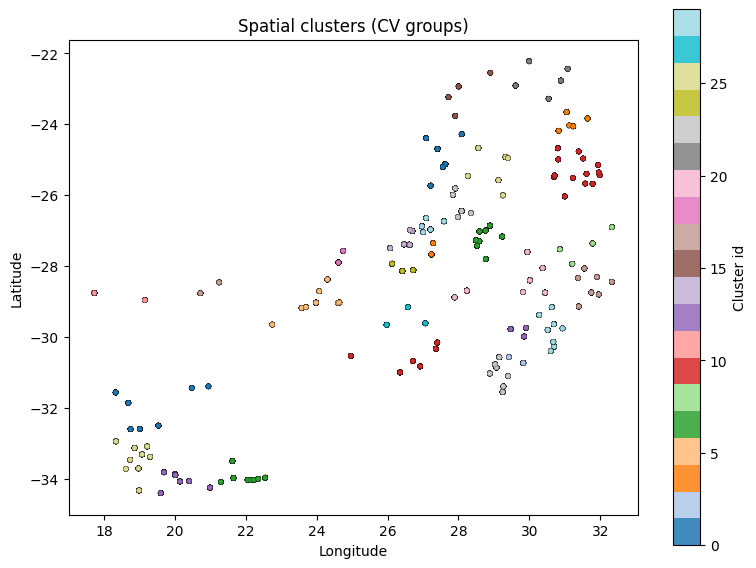

In [ ]:
N_CLUSTERS = 30
RANDOM_STATE = 42
groups = spatial_cluster_groups(lat_arr, lon_arr, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(8, 7))
sc = ax.scatter(lon_arr, lat_arr, c=groups, cmap="tab20", s=14, alpha=0.85, edgecolors="k", linewidths=0.2)
plt.colorbar(sc, ax=ax, label="Cluster id", shrink=0.8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial clusters (CV groups)")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

In [6]:
unique, counts = np.unique(groups, return_counts=True)
samples_per_cluster = dict(zip(unique, counts))
print("Samples per cluster:")
print("-" * 30)
for cid in unique[:15]:
    print(f"  Cluster {cid}: {counts[cid]} samples")
if len(unique) > 15:
    print(f"  ... ({len(unique) - 15} more clusters)")
print("-" * 30)
print(f"Min: {counts.min()}, Max: {counts.max()}, Mean: {counts.mean():.1f}, Median: {np.median(counts):.0f}")

Samples per cluster:
------------------------------
  Cluster 0: 520 samples
  Cluster 1: 241 samples
  Cluster 2: 113 samples
  Cluster 3: 174 samples
  Cluster 4: 173 samples
  Cluster 5: 487 samples
  Cluster 6: 753 samples
  Cluster 7: 403 samples
  Cluster 8: 179 samples
  Cluster 9: 381 samples
  Cluster 10: 284 samples
  Cluster 11: 97 samples
  Cluster 12: 339 samples
  Cluster 13: 231 samples
  Cluster 14: 685 samples
  ... (15 more clusters)
------------------------------
Min: 56, Max: 753, Mean: 310.6, Median: 270


## GroupKFold loop (concept)
Each fold: train on some clusters, test on **other** clusters — **no spatial leakage** between train and test within a fold.


# 3. Compare random CV vs spatial CV

Train a simple baseline model (LightGBM) and evaluate with:
- **Random KFold** — standard cross-validation (neighbors can appear in both train and test).
- **SpatialGroupKFold** — whole clusters held out per fold (no spatial leakage).

Compare out-of-fold RMSE. Typically **random CV underestimates error** when spatial autocorrelation exists; **spatial CV** gives a more realistic estimate for prediction at new locations.

In [7]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

try:
    import lightgbm as lgb
    BaselineModel = lgb.LGBMRegressor
    model_kw = dict(n_estimators=150, max_depth=6, random_state=RANDOM_STATE, verbose=-1)
except ImportError:
    from sklearn.ensemble import RandomForestRegressor
    BaselineModel = RandomForestRegressor
    model_kw = dict(n_estimators=100, max_depth=10, random_state=RANDOM_STATE)

target = "total_alkalinity"
if target not in df.columns:
    target = [c for c in TARGETS if c in df.columns][0]
cols = feature_columns(df, exclude_targets=True)
X = df[cols].copy()
X, _ = impute_median(X)
y = df[target].values
n_splits = 5

In [ ]:
# Random KFold
kf = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
oof_random = np.zeros(len(y))
for tr, te in kf.split(X):
    sc = StandardScaler().fit(X.iloc[tr])
    Xtr = pd.DataFrame(sc.transform(X.iloc[tr]), columns=X.columns)
    Xte = pd.DataFrame(sc.transform(X.iloc[te]), columns=X.columns)
    m = BaselineModel(**model_kw).fit(Xtr, y[tr])
    oof_random[te] = m.predict(Xte)
rmse_random = np.sqrt(mean_squared_error(y, oof_random))
r2_random = 1 - np.sum((y - oof_random) ** 2) / np.sum((y - np.mean(y)) ** 2)
print(f"Random KFold ({n_splits}-fold): RMSE = {rmse_random:.4f}, R² = {r2_random:.4f}")

Random KFold (5-fold): RMSE = 29.8705, R² = 0.8401


In [ ]:
# SpatialGroupKFold
sgkf = SpatialGroupKFold(n_splits=n_splits, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
oof_spatial = np.zeros(len(y))
for tr, te in sgkf.split(np.zeros((len(y), 1)), lat=lat_arr, lon=lon_arr):
    sc = StandardScaler().fit(X.iloc[tr])
    Xtr = pd.DataFrame(sc.transform(X.iloc[tr]), columns=X.columns)
    Xte = pd.DataFrame(sc.transform(X.iloc[te]), columns=X.columns)
    m = BaselineModel(**model_kw).fit(Xtr, y[tr])
    oof_spatial[te] = m.predict(Xte)
rmse_spatial = np.sqrt(mean_squared_error(y, oof_spatial))
r2_spatial = 1 - np.sum((y - oof_spatial) ** 2) / np.sum((y - np.mean(y)) ** 2)
print(f"SpatialGroupKFold ({n_splits}-fold): RMSE = {rmse_spatial:.4f}, R² = {r2_spatial:.4f}")

SpatialGroupKFold (5-fold): RMSE = 62.8457, R² = 0.2920


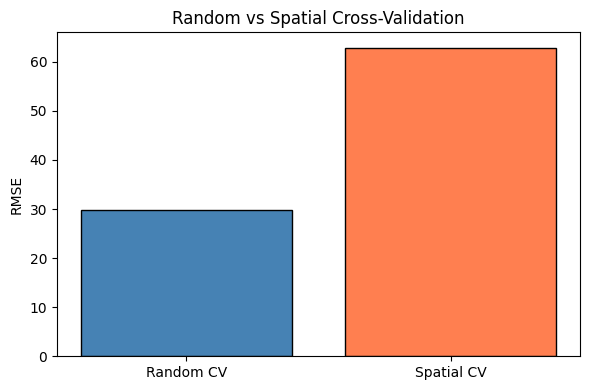

In [15]:
# Gráfico comparativo: Random vs Spatial CV
plt.figure(figsize=(6, 4))
methods = ["Random CV", "Spatial CV"]
rmse_vals = [rmse_random, rmse_spatial]
plt.bar(methods, rmse_vals, color=["steelblue", "coral"], edgecolor="k")
plt.ylabel("RMSE")
plt.title("Random vs Spatial Cross-Validation")
plt.tight_layout()
plt.show()

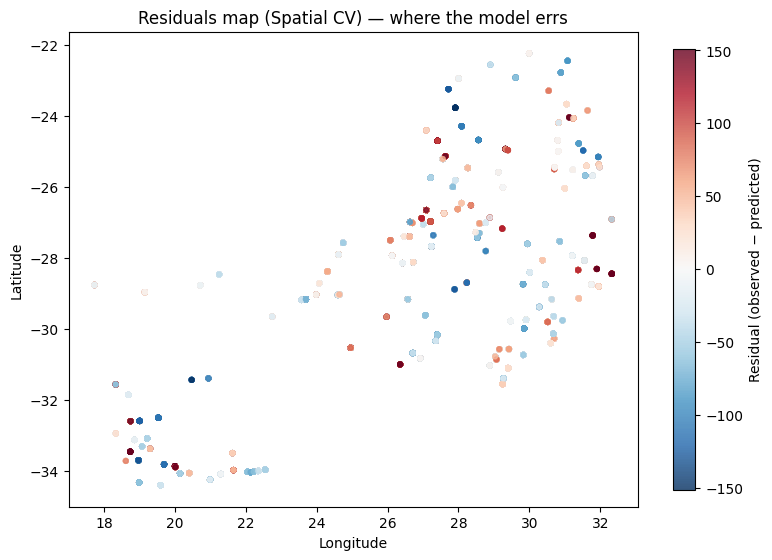

In [16]:
# Mapa de residuos (predicciones vs observaciones — Spatial CV)
# Muestra dónde el modelo falla más (residuos grandes en valor absoluto)
residuals = y - oof_spatial
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(lon_arr, lat_arr, c=residuals, cmap="RdBu_r", s=12, alpha=0.8, vmin=-np.percentile(np.abs(residuals), 98), vmax=np.percentile(np.abs(residuals), 98))
plt.colorbar(sc, ax=ax, label="Residual (observed − predicted)", shrink=0.8)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Residuals map (Spatial CV) — where the model errs")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

**Importante:** Un resultado como *Random R² = 0.84* y *Spatial R² = 0.29* **no significa que el modelo sea malo**. Significa que **tu evaluación es ahora HONESTA**. Con random CV, vecinos en train y test inflan el R²; con spatial CV se mide la capacidad de generalizar a ubicaciones no vistas. Muchos proyectos de ML geoespacial publican solo random CV y sobrestiman el rendimiento real; reportar spatial CV es la práctica correcta para predicción en nuevas localizaciones.

In [17]:
print("\nComparison (target =", target, "):")
print("-" * 50)
print(f"  {'Method':<22}  {'RMSE':>10}  {'R²':>8}")
print(f"  {'Random KFold':<22}  {rmse_random:>10.4f}  {r2_random:>8.4f}")
print(f"  {'SpatialGroupKFold':<22}  {rmse_spatial:>10.4f}  {r2_spatial:>8.4f}")
print("-" * 50)
if rmse_spatial > rmse_random:
    print("Spatial CV yields higher RMSE → random split was optimistic (spatial leakage).")
else:
    print("Spatial CV similar or better → less spatial structure in this target or small effect.")


Comparison (target = total_alkalinity ):
--------------------------------------------------
  Method                        RMSE        R²
  Random KFold               29.8705    0.8401
  SpatialGroupKFold          62.8457    0.2920
--------------------------------------------------
Spatial CV yields higher RMSE → random split was optimistic (spatial leakage).


**Why spatial CV is necessary:** When nearby observations are correlated (positive Moran's I), a random split lets the model "see" similar environments in both train and test. Performance looks better than it will be when predicting at truly new locations. SpatialGroupKFold holds out entire regions, so the model is evaluated on geographically distinct areas and the metrics reflect **generalization to new places**.

# 4. Interpretation

## Spatial structure of the dataset
- **Moran's I** (Section 1) quantifies whether target variables are spatially autocorrelated. Positive I implies that nearby sites tend to have similar values (e.g. shared catchment, climate, or geology).
- **Clustering** (Section 2) partitions the study area into spatial groups. The distribution of cluster sizes shows whether folds in SpatialGroupKFold will be balanced; very unequal sizes can make some folds much harder than others.

## Implications for model validation
- If **spatial autocorrelation is present**, random KFold typically **underestimates** prediction error because test points are often close to training points. **SpatialGroupKFold** gives a more honest estimate of performance when the goal is to predict at **new, unsampled locations** (e.g. new catchments or regions).
- For **mapping or management**, use metrics from spatial CV; for **interpolation within the sampled domain**, random CV may still be relevant depending on the application.

## Potential limitations of spatial generalization
- **Extrapolation in space:** Predictions in regions with no (or few) training samples may be unreliable; the model may not capture processes that vary geographically.
- **Cluster definition:** KMeans on (lat, lon) is scale-dependent and does not account for barriers (e.g. watersheds). Alternative groupings (e.g. by basin or distance) can be used if available.
- **Temporal and spatial non-stationarity:** Relationships between predictors and targets may change across space or time; spatial CV does not fully guard against that.

## GroupKFold fold structure (concept)

Each fold: train on some clusters, test on **other** clusters — no spatial leakage between train and test within a fold.

In [ ]:
sgkf = SpatialGroupKFold(n_splits=5, n_clusters=N_CLUSTERS, random_state=RANDOM_STATE)
X_dummy = np.zeros((len(df), 1))
for i, (tr, te) in enumerate(sgkf.split(X_dummy, lat=lat_arr, lon=lon_arr)):
    print(f"Fold {i}: train {len(tr)} | test {len(te)} | test clusters unique: {len(np.unique(groups[te]))}")

Fold 0: train 7460 | test 1859 | test clusters unique: 6
Fold 1: train 7460 | test 1859 | test clusters unique: 6
Fold 2: train 7432 | test 1887 | test clusters unique: 6
Fold 3: train 7454 | test 1865 | test clusters unique: 6
Fold 4: train 7470 | test 1849 | test clusters unique: 6


In [ ]:
sgkf = SpatialGroupKFold(n_splits=5, n_clusters=30)
X_dummy = np.zeros((len(df), 1))
for i, (tr, te) in enumerate(sgkf.split(X_dummy, lat=lat.values, lon=lon.values)):
    print(f"Fold {i}: train {len(tr)} | test {len(te)} | test clusters unique: {len(np.unique(groups[te]))}")


Fold 0: train 7460 | test 1859 | test clusters unique: 6
Fold 1: train 7460 | test 1859 | test clusters unique: 6
Fold 2: train 7432 | test 1887 | test clusters unique: 6
Fold 3: train 7454 | test 1865 | test clusters unique: 6
Fold 4: train 7470 | test 1849 | test clusters unique: 6
